<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h1 style="color:#e94560; text-align:center;">🏃 Athlete Performance Classification</h1>
<h3 style="color:#ffffff; text-align:center;">DS301 — Machine Learning Project</h3>
<p style="color:#a8a8b3; text-align:center;">
Dataset: Athlete Performance Evaluation | Models: LR · DT · KNN · RF
</p>
</div>

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📦 Step 1 — Imports & Load Data</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load all required libraries and read the dataset</p>
</div>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('/Users/admin/Downloads/athlete_performance_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget value counts:\n", df['performance_category'].value_counts())
df.head(10)

Shape: (1000, 20)

Columns: ['timestamp', 'heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'performance_score', 'performance_category']

Missing values:
 timestamp               0
heart_rate              0
oxygen_saturation       0
respiration_rate        0
body_temperature        0
hydration_level         0
speed                   0
acceleration            0
endurance_score         0
agility_score           0
reaction_time           0
workload                0
fatigue_index           0
feature_1               0
feature_2               0
feature_3               0
feature_4               0
feature_5               0
performance_score       0
performance_category    0
dtype: int64

Target value counts:
 performance_category
Medium    861
High       72
Low        67
Name: coun

,timestamp,heart_rate,oxygen_saturation,respiration_rate,body_temperature,hydration_level,speed,acceleration,endurance_score,agility_score,reaction_time,workload,fatigue_index,feature_1,feature_2,feature_3,feature_4,feature_5,performance_score,performance_category
0,2023-01-01 00:00:00,105.562916,91.851329,15.234114,38.018109,70.039711,5.755449,3.417156,3.879945,72.026792,469.752304,436.276737,0.533031,0.308613,0.948635,-0.853650,-0.000660,-0.991197,0.387548,Medium
1,2023-01-01 00:01:00,183.346431,95.419009,14.939576,38.390044,86.380263,6.314050,1.275739,18.677253,68.728300,333.876169,399.620887,0.137899,-0.839935,-0.965654,-0.821043,0.493494,-0.999340,0.483528,Medium
2,2023-01-01 00:02:00,153.819182,98.729458,28.125092,36.751404,83.211265,8.981832,4.425776,83.124581,9.575420,403.718595,258.538521,0.591243,-0.515340,0.895303,0.303947,0.125334,-0.055473,0.540403,Medium
3,2023-01-01 00:03:00,135.818895,97.322249,14.990924,37.874622,40.772993,5.380031,3.259023,76.676836,92.257240,302.616904,646.540003,0.314786,0.547359,-0.262645,-0.026119,-0.833395,-0.941413,0.684085,High
4,2023-01-01 00:04:00,76.062516,98.065611,15.438995,37.715238,40.447463,9.087548,1.207417,35.064269,56.847220,370.512102,528.961744,0.052349,0.057372,-0.979819,0.580831,-0.628840,0.949065,0.542811,Medium
5,2023-01-01 00:05:00,76.059260,96.587834,25.187965,38.498491,48.772206,3.616941,4.830521,37.681063,36.372552,269.201578,879.130893,0.948656,0.855938,0.378314,0.832542,-0.561344,-0.555870,0.394753,Medium
6,2023-01-01 00:06:00,62.841288,96.922766,18.994797,38.718261,55.275231,8.437589,2.832645,53.355443,75.653858,255.405657,128.898622,0.641490,-0.142497,0.961081,-0.223266,-0.484271,-0.054671,0.595068,Medium
7,2023-01-01 00:07:00,171.933780,98.491957,25.534211,36.036470,58.591891,8.932833,0.828043,0.024100,25.736546,352.380425,679.481135,0.876919,0.739625,0.931251,0.192820,0.130807,-0.877725,0.264835,Low
8,2023-01-01 00:08:00,136.150527,92.496680,11.307323,38.022060,77.578805,4.272724,3.320748,24.124434,69.350984,324.345386,786.653991,0.676056,-0.102089,-0.678126,0.001393,0.007932,0.044097,0.430807,Medium
9,2023-01-01 00:09:00,150.589798,94.894250,19.751424,36.155507,33.967630,6.012426,1.639395,20.823181,3.971121,352.837729,783.537912,0.356984,0.958497,-0.637504,0.963221,-0.593680,-0.240088,0.323576,Low


<div style="background-color:#533483; padding:15px; border-radius:10px; border-left:6px solid #ffcc00;">
<h2 style="color:#ffffff; margin:0;">🗑️ Step 2 — Drop Unnecessary Columns</h2>
<p style="color:#f0e6ff; margin:5px 0 0 0;">Remove timestamp, performance_score and unnamed feature columns</p>
</div>

In [20]:
df = df.drop(columns=['timestamp', 'performance_score',
                       'feature_1', 'feature_2', 'feature_3',
                       'feature_4', 'feature_5'])

print("Remaining columns:", df.columns.tolist())
print("New shape:", df.shape)

Remaining columns: ['heart_rate', 'oxygen_saturation', 'respiration_rate', 'body_temperature', 'hydration_level', 'speed', 'acceleration', 'endurance_score', 'agility_score', 'reaction_time', 'workload', 'fatigue_index', 'performance_category']
New shape: (1000, 13)


<div style="background-color:#065535; padding:15px; border-radius:10px; border-left:6px solid #00ff88;">
<h2 style="color:#ffffff; margin:0;">📊 Step 3 — Class Distribution</h2>
<p style="color:#b8ffdc; margin:5px 0 0 0;">Visualize target class balance: Low / Medium / High</p>
</div>

/var/folders/x8/rm3l4cwn0l1grxj_8w9hh4180000gn/T/ipykernel_4670/2069959804.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='performance_category', data=df,


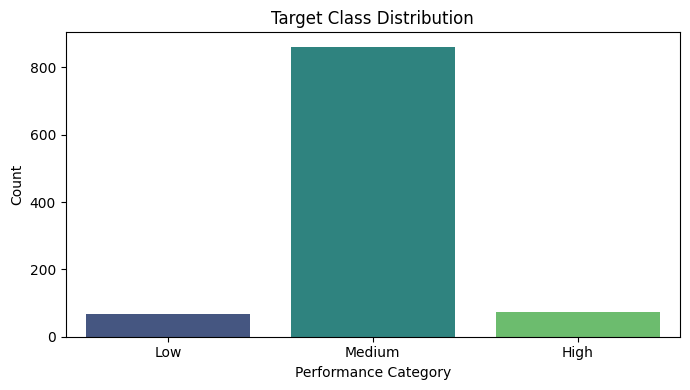

performance_category
Medium    861
High       72
Low        67
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(7, 4))
sns.countplot(x='performance_category', data=df,
              order=['Low', 'Medium', 'High'],
              palette='viridis')
plt.title('Target Class Distribution')
plt.xlabel('Performance Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/class_distribution.png')
plt.show()

print(df['performance_category'].value_counts())

<div style="background-color:#c94b4b; padding:15px; border-radius:10px; border-left:6px solid #ffffff;">
<h2 style="color:#ffffff; margin:0;">🌡️ Step 4 — Correlation Heatmap</h2>
<p style="color:#ffe0e0; margin:5px 0 0 0;">Check relationships between all numeric features</p>
</div>

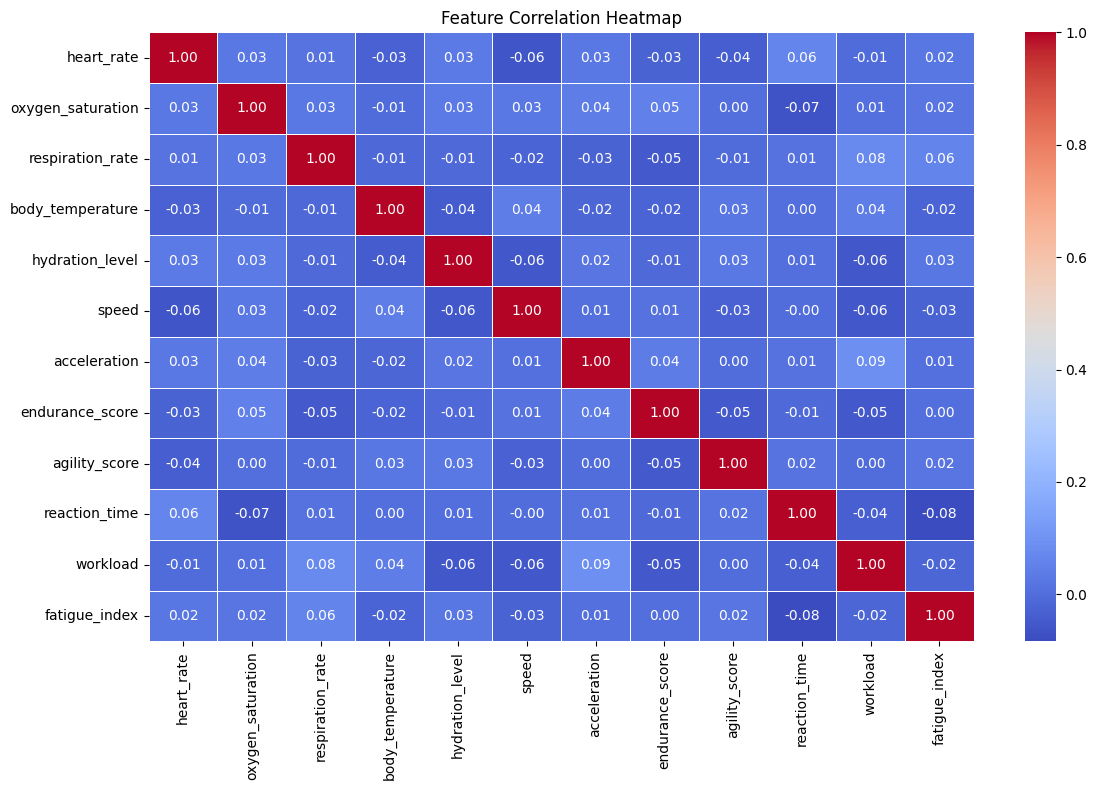

In [22]:
plt.figure(figsize=(12, 8))
numeric_df = df.drop(columns=['performance_category'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png')
plt.show()

<div style="background-color:#1a472a; padding:15px; border-radius:10px; border-left:6px solid #52b788;">
<h2 style="color:#ffffff; margin:0;">📈 Step 5 — Feature Distributions</h2>
<p style="color:#b7e4c7; margin:5px 0 0 0;">Box plots showing how each feature differs across performance levels</p>
</div>

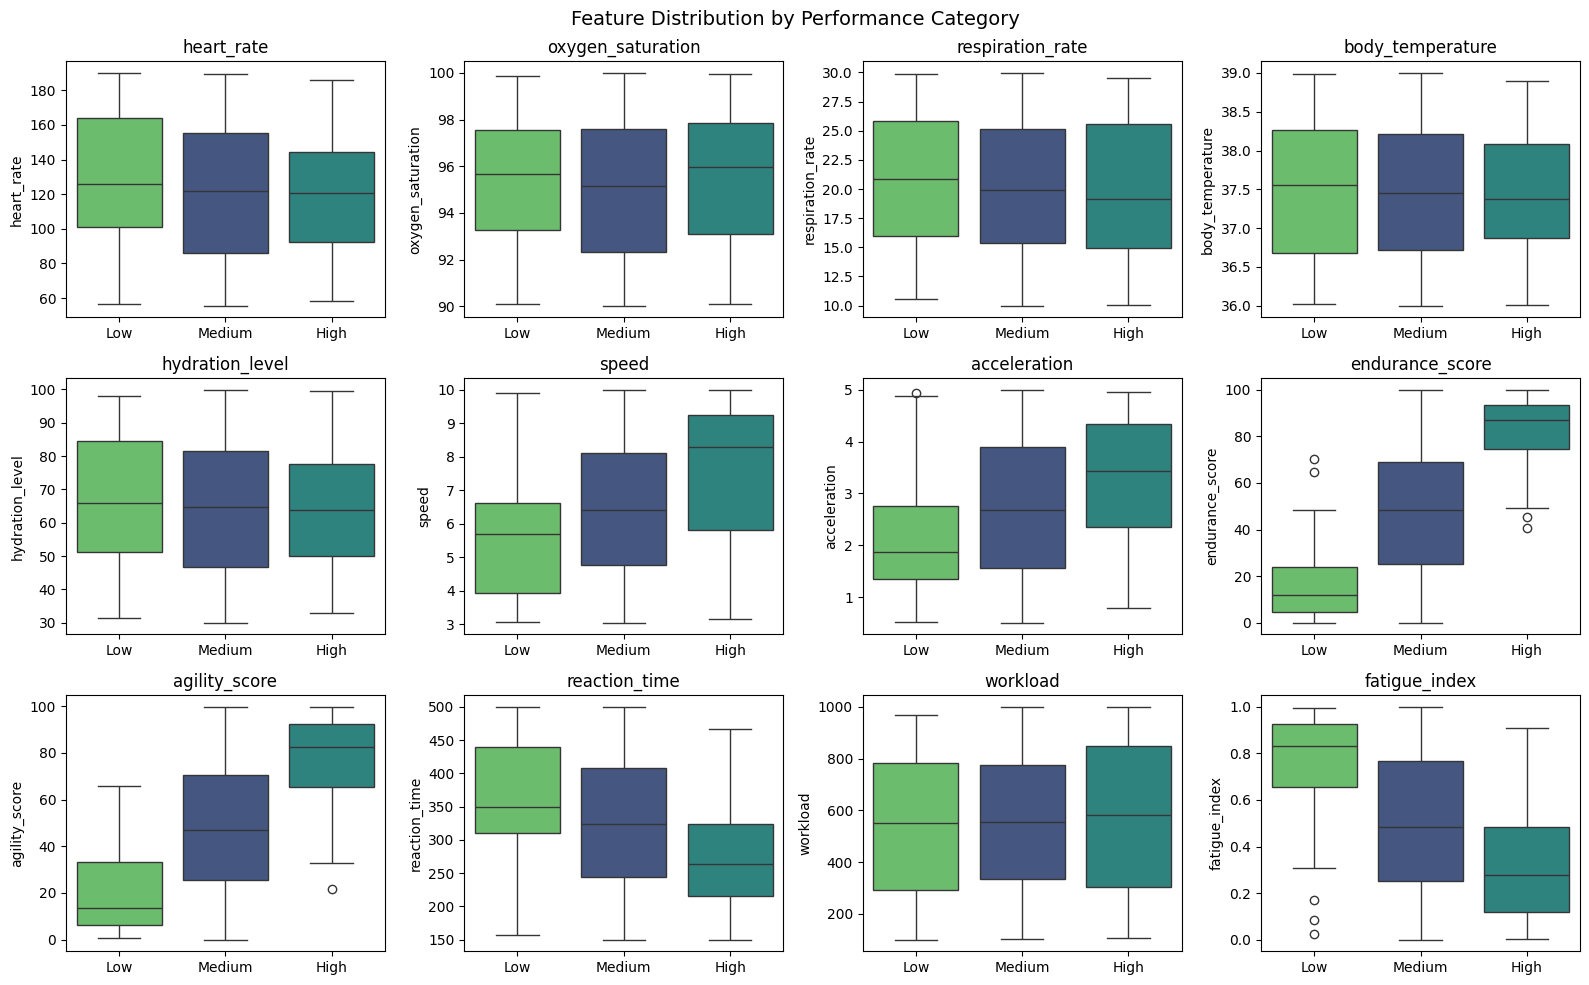

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
features = ['heart_rate', 'oxygen_saturation', 'respiration_rate',
            'body_temperature', 'hydration_level', 'speed',
            'acceleration', 'endurance_score', 'agility_score',
            'reaction_time', 'workload', 'fatigue_index']

for i, feature in enumerate(features):
    ax = axes[i//4, i%4]
    sns.boxplot(x='performance_category', y=feature, data=df,
                order=['Low', 'Medium', 'High'], ax=ax,
                hue='performance_category', legend=False, palette='viridis')
    ax.set_title(feature)
    ax.set_xlabel('')

plt.suptitle('Feature Distribution by Performance Category', fontsize=14)
plt.tight_layout()
plt.savefig('../results/feature_distributions.png')
plt.show()

<div style="background-color:#03045e; padding:15px; border-radius:10px; border-left:6px solid #00b4d8;">
<h2 style="color:#ffffff; margin:0;">⚙️ Step 6 — Preprocessing & Splits</h2>
<p style="color:#90e0ef; margin:5px 0 0 0;">Label encode target · 80/20 & 70/30 splits · RobustScaler for LR & KNN</p>
</div>

In [24]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(df['performance_category'])
X = df.drop(columns=['performance_category'])

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 80/20 split
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 70/30 split
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Scale for LR and KNN only
scaler = RobustScaler()
X_train_80_sc = scaler.fit_transform(X_train_80)
X_test_80_sc  = scaler.transform(X_test_80)
X_train_70_sc = scaler.fit_transform(X_train_70)
X_test_70_sc  = scaler.transform(X_test_70)

print("80/20 — Train:", X_train_80.shape, "Test:", X_test_80.shape)
print("70/30 — Train:", X_train_70.shape, "Test:", X_test_70.shape)

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
80/20 — Train: (800, 12) Test: (200, 12)
70/30 — Train: (700, 12) Test: (300, 12)


<div style="background-color:#7b2d8b; padding:15px; border-radius:10px; border-left:6px solid #ff9ef5;">
<h2 style="color:#ffffff; margin:0;">🤖 Step 7 — Train All 4 Models</h2>
<p style="color:#f9d4ff; margin:5px 0 0 0;">Logistic Regression · Decision Tree · KNN · Random Forest</p>
</div>

In [25]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_80_sc, y_train_80)
lr_pred_80 = lr.predict(X_test_80_sc)
lr.fit(X_train_70_sc, y_train_70)
lr_pred_70 = lr.predict(X_test_70_sc)

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_80, y_train_80)
dt_pred_80 = dt.predict(X_test_80)
dt.fit(X_train_70, y_train_70)
dt_pred_70 = dt.predict(X_test_70)

# 3. KNN
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_80_sc, y_train_80)
knn_pred_80 = knn.predict(X_test_80_sc)
knn.fit(X_train_70_sc, y_train_70)
knn_pred_70 = knn.predict(X_test_70_sc)

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_80, y_train_80)
rf_pred_80 = rf.predict(X_test_80)
rf.fit(X_train_70, y_train_70)
rf_pred_70 = rf.predict(X_test_70)

print("✅ All 4 models trained on both splits!")

✅ All 4 models trained on both splits!


<div style="background-color:#b5451b; padding:15px; border-radius:10px; border-left:6px solid #ffdd57;">
<h2 style="color:#ffffff; margin:0;">📉 Step 8 — Evaluate All Models</h2>
<p style="color:#fff3b0; margin:5px 0 0 0;">Confusion matrices · Accuracy · Precision · Recall · F1-score</p>
</div>


===== 80/20 SPLIT =====

  Logistic Regression 80_20
Accuracy: 0.9600
              precision    recall  f1-score   support

        High       1.00      0.53      0.70        15
         Low       1.00      0.92      0.96        13
      Medium       0.96      1.00      0.98       172

    accuracy                           0.96       200
   macro avg       0.99      0.82      0.88       200
weighted avg       0.96      0.96      0.96       200



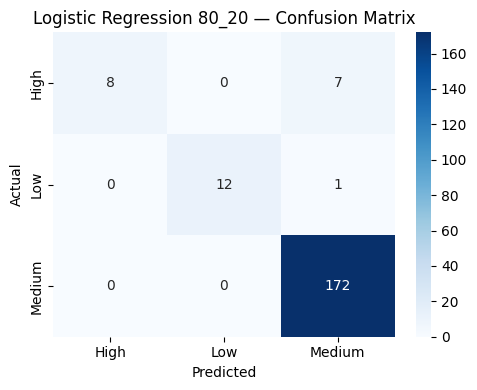


  Decision Tree 80_20
Accuracy: 0.8850
              precision    recall  f1-score   support

        High       0.75      0.40      0.52        15
         Low       0.55      0.46      0.50        13
      Medium       0.91      0.96      0.93       172

    accuracy                           0.89       200
   macro avg       0.74      0.61      0.65       200
weighted avg       0.88      0.89      0.88       200



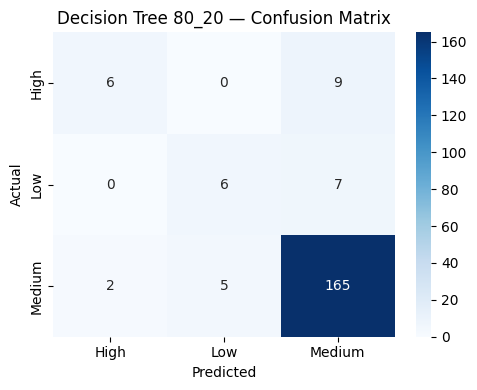


  KNN 80_20
Accuracy: 0.8750
              precision    recall  f1-score   support

        High       1.00      0.07      0.12        15
         Low       1.00      0.15      0.27        13
      Medium       0.87      1.00      0.93       172

    accuracy                           0.88       200
   macro avg       0.96      0.41      0.44       200
weighted avg       0.89      0.88      0.83       200



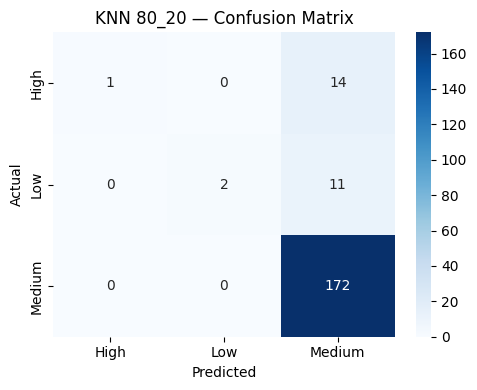


  Random Forest 80_20
Accuracy: 0.8800
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        15
         Low       1.00      0.31      0.47        13
      Medium       0.88      1.00      0.93       172

    accuracy                           0.88       200
   macro avg       0.63      0.44      0.47       200
weighted avg       0.82      0.88      0.83       200



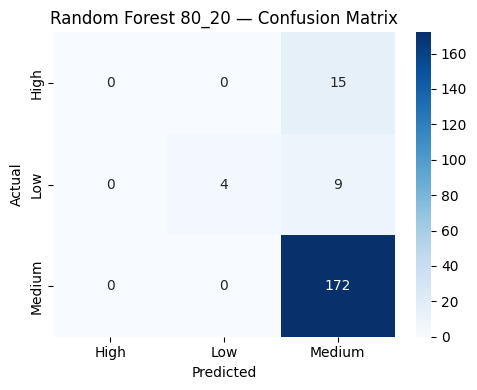


===== 70/30 SPLIT =====

  Logistic Regression 70_30
Accuracy: 0.9500
              precision    recall  f1-score   support

        High       1.00      0.50      0.67        22
         Low       1.00      0.80      0.89        20
      Medium       0.95      1.00      0.97       258

    accuracy                           0.95       300
   macro avg       0.98      0.77      0.84       300
weighted avg       0.95      0.95      0.94       300



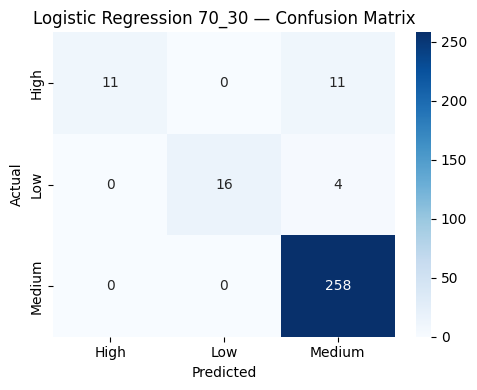


  Decision Tree 70_30
Accuracy: 0.8633
              precision    recall  f1-score   support

        High       0.60      0.41      0.49        22
         Low       0.44      0.55      0.49        20
      Medium       0.92      0.93      0.92       258

    accuracy                           0.86       300
   macro avg       0.65      0.63      0.63       300
weighted avg       0.86      0.86      0.86       300



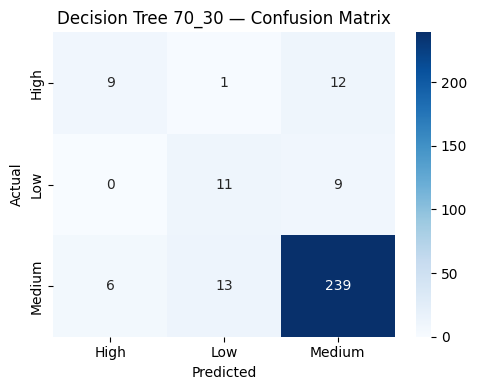


  KNN 70_30
Accuracy: 0.8733
              precision    recall  f1-score   support

        High       1.00      0.09      0.17        22
         Low       1.00      0.10      0.18        20
      Medium       0.87      1.00      0.93       258

    accuracy                           0.87       300
   macro avg       0.96      0.40      0.43       300
weighted avg       0.89      0.87      0.83       300



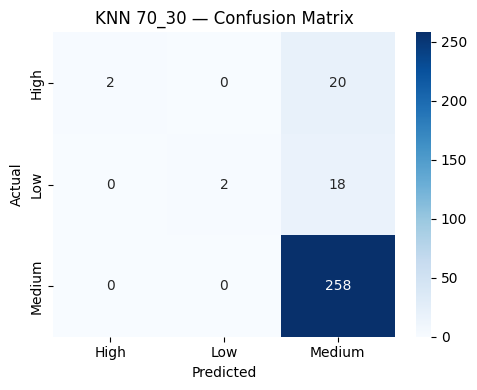


  Random Forest 70_30
Accuracy: 0.8800
              precision    recall  f1-score   support

        High       1.00      0.05      0.09        22
         Low       1.00      0.25      0.40        20
      Medium       0.88      1.00      0.93       258

    accuracy                           0.88       300
   macro avg       0.96      0.43      0.47       300
weighted avg       0.89      0.88      0.84       300



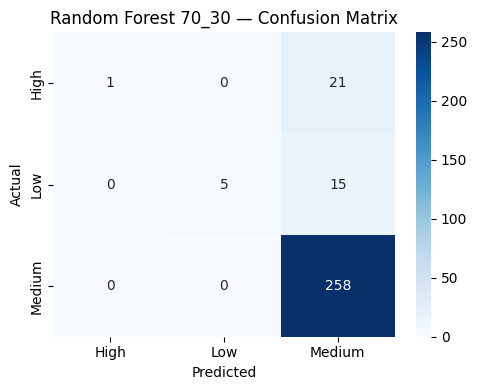

In [26]:
os.makedirs('../results', exist_ok=True)

def evaluate(name, y_test, y_pred, classes):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=classes,
                                 zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f'../results/cm_{safe_name}.png')
    plt.show()

classes = le.classes_

print("\n===== 80/20 SPLIT =====")
evaluate("Logistic Regression 80_20", y_test_80, lr_pred_80, classes)
evaluate("Decision Tree 80_20",       y_test_80, dt_pred_80, classes)
evaluate("KNN 80_20",                 y_test_80, knn_pred_80, classes)
evaluate("Random Forest 80_20",       y_test_80, rf_pred_80, classes)

print("\n===== 70/30 SPLIT =====")
evaluate("Logistic Regression 70_30", y_test_70, lr_pred_70, classes)
evaluate("Decision Tree 70_30",       y_test_70, dt_pred_70, classes)
evaluate("KNN 70_30",                 y_test_70, knn_pred_70, classes)
evaluate("Random Forest 70_30",       y_test_70, rf_pred_70, classes)

<div style="background-color:#0d3b66; padding:15px; border-radius:10px; border-left:6px solid #ffd166;">
<h2 style="color:#ffffff; margin:0;">🔍 Step 9 — Find Best K for KNN</h2>
<p style="color:#ffe8a3; margin:5px 0 0 0;">Elbow curve to find optimal K value</p>
</div>

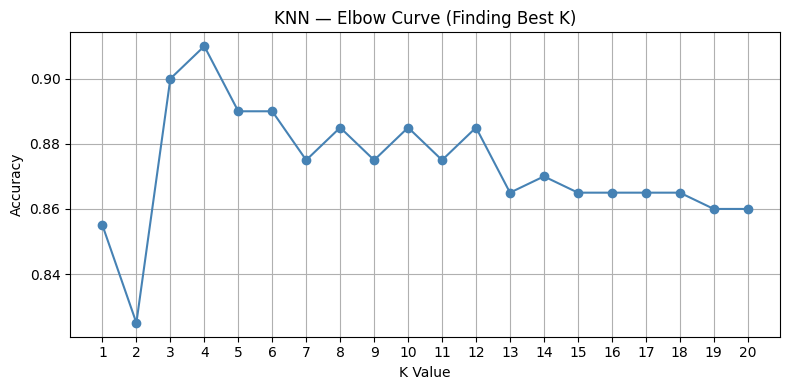

Best K = 4 with accuracy = 0.9100


In [27]:
k_scores = []
for k in range(1, 21):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_80_sc, y_train_80)
    k_scores.append(accuracy_score(y_test_80, knn_k.predict(X_test_80_sc)))

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), k_scores, marker='o', color='steelblue')
plt.title('KNN — Elbow Curve (Finding Best K)')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(range(1, 21))
plt.grid(True)
plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/knn_elbow.png')
plt.show()

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K = {best_k} with accuracy = {max(k_scores):.4f}")

<div style="background-color:#2d6a4f; padding:15px; border-radius:10px; border-left:6px solid #95d5b2;">
<h2 style="color:#ffffff; margin:0;">🔄 Step 10 — 5-Fold Cross Validation</h2>
<p style="color:#d8f3dc; margin:5px 0 0 0;">Test model stability across 5 different data splits</p>
</div>

In [28]:
cv_results = {}

models_cv = {
    'Logistic Regression': (LogisticRegression(max_iter=1000,
                            random_state=42), True),
    'Decision Tree':       (DecisionTreeClassifier(random_state=42),
                            False),
    'KNN':                 (KNeighborsClassifier(n_neighbors=best_k),
                            True),
    'Random Forest':       (RandomForestClassifier(n_estimators=100,
                            random_state=42), False),
}

print("5-Fold Cross Validation Results:")
print("-" * 40)
for name, (model, scale) in models_cv.items():
    data = RobustScaler().fit_transform(X) if scale else X
    scores = cross_val_score(model, data, y, cv=5)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Mean = {scores.mean():.4f}")
    print(f"  Std  = {scores.std():.4f}")
    print(f"  All folds = {[round(s,4) for s in scores]}")
    print()

5-Fold Cross Validation Results:
----------------------------------------
Logistic Regression:
  Mean = 0.9620
  Std  = 0.0068
  All folds = [np.float64(0.965), np.float64(0.96), np.float64(0.95), np.float64(0.965), np.float64(0.97)]

Decision Tree:
  Mean = 0.8400
  Std  = 0.0255
  All folds = [np.float64(0.88), np.float64(0.86), np.float64(0.825), np.float64(0.815), np.float64(0.82)]

KNN:
  Mean = 0.8920
  Std  = 0.0194
  All folds = [np.float64(0.875), np.float64(0.87), np.float64(0.925), np.float64(0.895), np.float64(0.895)]

Random Forest:
  Mean = 0.8850
  Std  = 0.0089
  All folds = [np.float64(0.89), np.float64(0.88), np.float64(0.895), np.float64(0.87), np.float64(0.89)]



<div style="background-color:#370617; padding:15px; border-radius:10px; border-left:6px solid #f48c06;">
<h2 style="color:#ffffff; margin:0;">🏆 Step 11 — Final Model Comparison</h2>
<p style="color:#ffba08; margin:5px 0 0 0;">Compare all models — Split Accuracy vs CV Mean</p>
</div>


📊 Final Model Comparison:
                     Split Accuracy  CV Mean
Logistic Regression           0.960    0.962
Decision Tree                 0.885    0.840
Random Forest                 0.880    0.885
KNN                           0.875    0.892


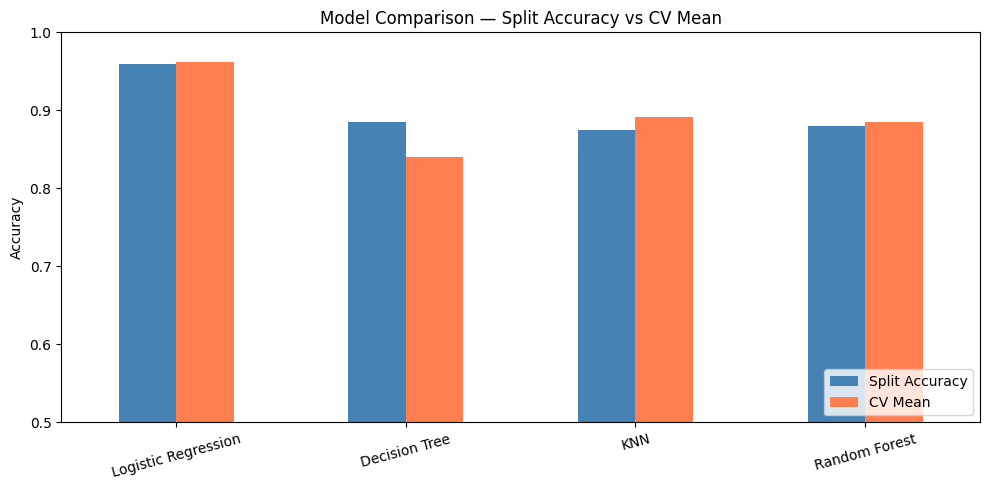

In [29]:
split_acc = {
    'Logistic Regression': accuracy_score(y_test_80, lr_pred_80),
    'Decision Tree':       accuracy_score(y_test_80, dt_pred_80),
    'KNN':                 accuracy_score(y_test_80, knn_pred_80),
    'Random Forest':       accuracy_score(y_test_80, rf_pred_80),
}

cv_means = {name: scores.mean() for name, scores in cv_results.items()}

comparison_df = pd.DataFrame({
    'Split Accuracy': split_acc,
    'CV Mean':        cv_means
})

print("\n📊 Final Model Comparison:")
print("=" * 45)
print(comparison_df.sort_values('Split Accuracy', ascending=False).round(4))

comparison_df.plot(kind='bar', figsize=(10, 5),
                   color=['steelblue', 'coral'])
plt.title('Model Comparison — Split Accuracy vs CV Mean')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/model_comparison.png')
plt.show()

<div style="background-color:#212529; padding:15px; border-radius:10px; border-left:6px solid #adb5bd;">
<h2 style="color:#ffffff; margin:0;">⭐ Step 12 — Feature Importance</h2>
<p style="color:#ced4da; margin:5px 0 0 0;">Which features matter most for predicting athlete performance?</p>
</div>

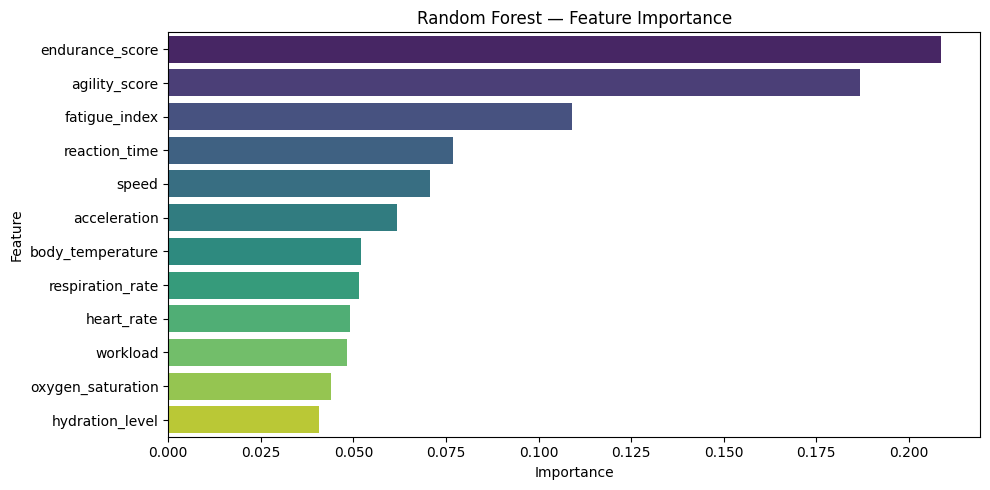

              Feature  Importance
7     endurance_score    0.208783
8       agility_score    0.186898
11      fatigue_index    0.109160
9       reaction_time    0.076954
5               speed    0.070679
6        acceleration    0.061773
3    body_temperature    0.052070
2    respiration_rate    0.051403
0          heart_rate    0.049207
10           workload    0.048330
1   oxygen_saturation    0.044062
4     hydration_level    0.040681


In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance,
            hue='Feature', legend=False,
            palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/feature_importance.png')
plt.show()

print(feature_importance)

<div style="background-color:#1a1a2e; padding:20px; border-radius:10px; border:2px solid #e94560;">
<h2 style="color:#e94560; text-align:center;">🎯 Key Findings</h2>
<table style="width:100%; color:white; border-collapse:collapse;">
<tr style="background-color:#0f3460;">
<th style="padding:10px; border:1px solid #e94560;">Model</th>
<th style="padding:10px; border:1px solid #e94560;">Split Accuracy</th>
<th style="padding:10px; border:1px solid #e94560;">CV Mean</th>
</tr>
<tr>
<td style="padding:10px; border:1px solid #333; color:#ffcc00;">🥇 Logistic Regression</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">96.0%</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">96.2%</td>
</tr>
<tr>
<td style="padding:10px; border:1px solid #333;">Decision Tree</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">88.5%</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">84.0%</td>
</tr>
<tr>
<td style="padding:10px; border:1px solid #333;">Random Forest</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">88.0%</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">88.5%</td>
</tr>
<tr>
<td style="padding:10px; border:1px solid #333;">KNN (K=4)</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">87.5%</td>
<td style="padding:10px; border:1px solid #333; text-align:center;">89.2%</td>
</tr>
</table>
<p style="color:#a8d8ea; margin-top:15px;">
⚠️ <b>Limitation:</b> Heavy class imbalance (86% Medium) — suggest SMOTE as improvement<br>
⭐ <b>Top Features:</b> endurance_score · agility_score · fatigue_index
</p>
</div>